Compute mean connectivity from HCP7T dataset

In [2]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from glob import glob

In [3]:
tian_scale = 'S2'

lut_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-carpet',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-carpet_lut.tsv')

region_list = list(pd.read_csv(lut_fpath, sep='\t', header=None).iloc[:,1])

In [4]:
region_list

['aPUT-lh',
 'pPUT-lh',
 'aCAU-lh',
 'pCAU-lh',
 'aPUT-rh',
 'pPUT-rh',
 'aCAU-rh',
 'pCAU-rh',
 'L-HG',
 'L-PP',
 'L-PT',
 'L-STGa',
 'L-STGp',
 'R-HG',
 'R-PP',
 'R-PT',
 'R-STGa',
 'R-STGp',
 'L-LOCsup',
 'L-LOCinf',
 'L-IntraCalc',
 'L-TempOccFus',
 'L-OccFus',
 'L-SupraCalc',
 'L-OccPole',
 'R-LOCsup',
 'R-LOCinf',
 'R-IntraCalc',
 'R-TempOccFus',
 'R-OccFus',
 'R-SupraCalc',
 'R-OccPole']

In [5]:
data_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                        'HCP_7T_diffusion/msmt_csd_nthreads-1/')

## Read in participant connectivity matrices

In [6]:
print(data_dir + 
      '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv')

/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1//*/connectome_streamlines_alg-iFOD2_nsl-10mil/atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv


In [7]:
conn_files = sorted(glob(data_dir + 
                         '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         f'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv'))

# derive participant IDs directly from conn_files (preserves same order)
participants_with_files = sorted(list({os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(p)))) for p in conn_files}))


In [8]:
print(len(conn_files))

96


In [9]:
test_df = pd.read_csv(conn_files[0], header=None)
print(test_df)
print(len(test_df))


             0            1            2            3            4   \
0   8268.074209  3171.177498  2156.096386   828.728846    80.337416   
1   3171.177498  3677.825174   304.758787  1126.495766    67.175016   
2   2156.096386   304.758787  8997.764935  1554.796652    69.710324   
3    828.728846  1126.495766  1554.796652  3014.341623    30.107019   
4     80.337416    67.175016    69.710324    30.107019  9985.398348   
5    105.360801   189.179635    15.751270    97.746538  3218.237984   
6     24.730155    10.277543    31.992937    21.574194  3155.990691   
7     27.268470    21.221287    19.345882    51.452262   237.809434   
8     65.834432  3104.246460     4.357843    19.704495     0.280541   
9   1039.054971  4790.470911    32.089380    63.850731    17.240047   
10   285.033913  1161.845649    29.873710    63.258076     0.000000   
11    17.673466   303.012608     1.401305     5.224105     0.000000   
12    85.995214   168.422050     7.799678    23.021013     0.000000   
13    

In [10]:
# loop through each subject's connectivity matrix and clean up the formatting
num_regions = len(test_df) # number of regions of interest in the HCP analysis
num_subjects = len(conn_files)
connmats_raw = np.zeros((num_subjects, num_regions, num_regions))
slcounts = np.zeros((num_regions, num_subjects))
list_df = []
for sx, matrix_fpath in enumerate(conn_files):

    sub_df = pd.read_csv(matrix_fpath, header=None)
    list_df.append(sub_df)
    
    connmats_raw[sx,:,:] = sub_df.to_numpy()
    
    slcounts[:,sx] = sub_df.to_numpy().sum(axis=0) # sub_df.iloc[:,0]

In [11]:
threshold = 1.0
connmats = np.where(connmats_raw >= threshold, connmats_raw, 0.0)


In [12]:
np.shape(connmats)

(96, 32, 32)

In [13]:
# check the streamline count matrix (region x subject)
slcounts

array([[1.76549240e+04, 1.23438669e+04, 1.62320679e+04, ...,
        1.22546618e+00, 1.40319727e+00, 1.58966587e+00],
       [2.87630393e+04, 2.45096872e+04, 3.39282210e+04, ...,
        2.50707697e+00, 2.90795179e+00, 3.48593396e+00],
       [1.33349388e+04, 3.81352467e+03, 6.33383022e+03, ...,
        1.33146244e+00, 2.39993079e+00, 1.42717371e+00],
       ...,
       [1.36109862e+05, 1.31451117e+05, 8.74709999e+04, ...,
        5.92345496e+00, 6.03157280e+00, 7.41906025e+00],
       [1.46672655e+04, 2.05444162e+04, 2.79056571e+04, ...,
        1.24304271e+00, 2.91927144e+00, 1.65354611e+00],
       [1.77609962e+05, 1.23138864e+05, 1.28152539e+05, ...,
        2.47380257e+00, 2.44083286e+00, 2.95087768e+00]])

In [14]:
slcounts[0,:]

array([1.76549240e+04, 1.23438669e+04, 1.62320679e+04, 1.34106256e+04,
       1.10093724e+04, 9.13794657e+03, 1.34044247e+04, 1.10465835e+04,
       1.32685602e+04, 1.44412994e+04, 1.42371272e+04, 1.81507005e+04,
       1.07186078e+04, 1.79893258e+04, 9.34883685e+03, 1.53932314e+04,
       1.43629094e+04, 4.57719069e+03, 1.04952311e+04, 1.37204802e+04,
       1.00731076e+04, 1.76689577e+04, 1.18400797e+04, 1.36310386e+04,
       1.25054617e+04, 2.11918492e+04, 1.59622642e+04, 1.44644173e+04,
       1.16016733e+04, 1.50002579e+04, 9.86614231e+03, 1.11063599e+04,
       1.15845928e+04, 1.21713971e+04, 1.01572864e+04, 1.36965965e+04,
       1.30373079e+04, 8.93040127e+03, 1.29972390e+04, 1.59158732e+04,
       1.09201880e+04, 1.16059353e+04, 1.01205020e+04, 8.63078626e+03,
       1.57881634e+04, 7.93875283e+03, 1.20085217e+04, 1.06939969e+04,
       1.42974071e+04, 1.48577429e+04, 7.28405413e+03, 1.28721134e+04,
       1.38320985e+04, 1.61681470e+04, 8.44753356e+03, 1.08991994e+04,
      

## Compute mean streamline count per ROI

In [15]:
# compute the mean streamline count per IC subdivision
mean_slcount = slcounts.mean(axis=1)
print(mean_slcount)
print(mean_slcount.shape)

[ 10010.19541179  19958.99009649   6302.19596174   4330.70264329
  12278.77500188  22121.2629355    6786.24167321   5601.02329044
  24476.14633827  31896.51286142  41810.68840283  23737.78181133
  34342.55773441  23742.23605477  26954.10324392  37654.0310592
  14443.2960992   44088.86050703 169163.48228434  98903.83345973
  47016.49948266  51576.39513469      0.          17494.55343904
 143691.23173848 146777.39451772 101886.18581357  47034.70941246
  48479.33676951  91810.91322037  14122.83275843 103808.03849364]
(32,)


In [16]:
mean_connmat = connmats.mean(axis=0)

print(mean_connmat)
print(mean_connmat.shape)

[[3.70215541e+03 1.84673000e+03 1.11712140e+03 ... 6.53827017e+02
  3.45712835e-02 1.41402579e-02]
 [1.84673000e+03 2.78843216e+03 1.34957741e+02 ... 7.47175856e+02
  2.99776479e+00 2.17370647e+00]
 [1.11712140e+03 1.34957741e+02 3.61986665e+03 ... 2.43030813e+01
  6.24407165e-02 0.00000000e+00]
 ...
 [6.53827017e+02 7.47175856e+02 2.43030813e+01 ... 4.06699901e+04
  2.57142210e+01 1.75825947e+01]
 [3.45712835e-02 2.99776479e+00 6.24407165e-02 ... 2.57142210e+01
  1.58913042e+03 2.13580466e+03]
 [1.41402579e-02 2.17370647e+00 0.00000000e+00 ... 1.75825947e+01
  2.13580466e+03 5.67209955e+04]]
(32, 32)


In [17]:

# add ROI names to df
mean_df = pd.DataFrame(mean_connmat, columns=region_list)
mean_df.insert(0, 'seed', region_list)
mean_df.insert(0, 'mean_slcount', mean_slcount)


In [18]:
mean_df

,mean_slcount,seed,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,10010.195412,aPUT-lh,3702.155407,1846.730001,1117.121405,246.911617,18.182579,15.634243,21.509473,14.708151,...,0.0,19.553401,164.805122,0.000000,0.023220,0.809282,3.608018,653.827017,0.034571,0.014140
1,19958.990096,pPUT-lh,1846.730001,2788.432156,134.957741,631.050883,13.433735,38.792259,8.047073,20.013324,...,0.0,52.118167,2270.087066,4.426675,0.000000,4.249206,3.470450,747.175856,2.997765,2.173706
2,6302.195962,aCAU-lh,1117.121405,134.957741,3619.866653,1162.729424,18.453303,9.416898,67.921339,26.743611,...,0.0,4.776459,0.000000,0.081981,0.000000,1.095069,0.630192,24.303081,0.062441,0.000000
3,4330.702643,pCAU-lh,246.911617,631.050883,1162.729424,1796.529814,15.028995,33.362579,34.556751,74.927077,...,0.0,2.220486,7.815765,0.613589,0.000000,0.099726,0.426208,5.558591,0.064791,0.000000
4,12278.775002,aPUT-rh,18.182579,13.433735,18.453303,15.028995,4753.809543,2116.104969,952.240204,185.447185,...,0.0,0.033904,0.000000,719.881263,261.456218,366.389221,114.630460,1.287948,14.305258,282.154831
5,22121.262936,pPUT-rh,15.634243,38.792259,9.416898,33.362579,2116.104969,2866.036917,145.912086,624.936166,...,0.0,6.999977,0.111779,4506.986746,554.019530,343.590784,173.679713,0.092574,30.532139,2611.186363
6,6786.241673,aCAU-rh,21.509473,8.047073,67.921339,34.556751,952.240204,145.912086,3533.499511,1891.896371,...,0.0,0.000000,0.000000,23.815182,3.866252,11.231834,9.602845,0.137724,1.066273,0.097300
7,5601.023290,pCAU-rh,14.708151,20.013324,26.743611,74.927077,185.447185,624.936166,1891.896371,2393.654910,...,0.0,0.023160,0.000000,166.861599,11.283727,3.728854,4.175991,0.000000,0.331285,4.299919
8,24476.146338,L-HG,74.892268,2424.333473,3.982818,4.870631,0.011521,2.646291,0.041571,0.159254,...,0.0,6.611584,19.303948,3.061257,0.000000,0.804879,0.051549,6.894829,0.855454,0.000000
9,31896.512861,L-PP,830.059621,3357.545100,40.238416,68.435067,2.966095,3.839121,1.918882,1.830597,...,0.0,49.173102,1270.742201,0.189969,0.000000,1.863617,0.261716,646.903745,0.846025,1.201160


In [19]:
# save the mean data
out_dir = os.path.join(data_dir, 'group_plots_Apr')
out_fpath = os.path.join(out_dir, 'pd_mean_connectivity_scale-invnodevol_sub-thresh-1.txt')
os.makedirs(out_dir, exist_ok=True)
mean_df.to_csv(out_fpath, sep='\t', index=False)

#### Threshold low/null values

In [20]:
# Check distribution of non-zero values to pick a threshold
numeric_cols = mean_df.select_dtypes(include='number').columns
values = mean_df[numeric_cols].values.flatten()
values = values[values > 0]
pd.Series(values).describe(percentiles=[.01, .05, .1, .25])


count       878.000000
mean       3353.717757
std       13904.735000
min           0.010466
1%            0.013609
5%            0.033077
10%           0.093745
25%           1.914210
50%          26.743611
max      169163.482284
dtype: float64

In [21]:
threshold = 1.0  # adjust based on distribution
numeric_cols = mean_df.select_dtypes(include='number').columns
mean_df_thresh = mean_df.copy()
mean_df_thresh[numeric_cols] = mean_df_thresh[numeric_cols].where(
    mean_df_thresh[numeric_cols] >= threshold, other=0.0
)


In [22]:
# save the thresholded mean data
out_dir = os.path.join(data_dir, 'group_plots_Apr')
out_fpath = os.path.join(out_dir, 'pd_mean_connectivity_scale-invnodevol_thresh-1.txt')
os.makedirs(out_dir, exist_ok=True)
mean_df_thresh.to_csv(out_fpath, sep='\t', index=False)

### Plot distributions

In [23]:
connmats.shape

(96, 32, 32)

<Axes: >

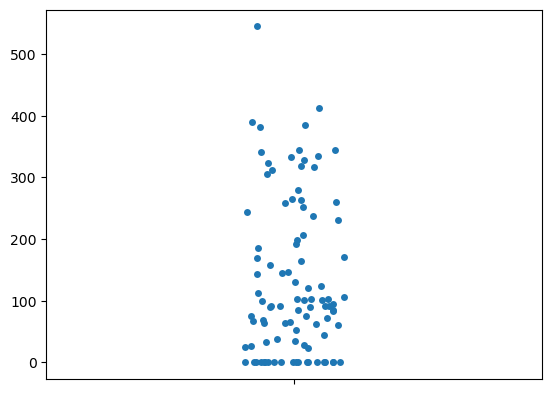

In [24]:
sns.stripplot(connmats[:,1,2])

## Connectivity plots

In [25]:
num_participants = len(connmats)
print('Number of participants:', num_participants)

Number of participants: 96


In [26]:
plot_df = mean_df_thresh.iloc[:, 2:]


In [27]:
plot_df

,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,L-HG,L-PP,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,3702.155407,1846.730001,1117.121405,246.911617,18.182579,15.634243,21.509473,14.708151,74.892268,830.059621,...,0.0,19.553401,164.805122,0.000000,0.000000,0.000000,3.608018,653.827017,0.000000,0.000000
1,1846.730001,2788.432156,134.957741,631.050883,13.433735,38.792259,8.047073,20.013324,2424.333473,3357.545100,...,0.0,52.118167,2270.087066,4.426675,0.000000,4.249206,3.470450,747.175856,2.997765,2.173706
2,1117.121405,134.957741,3619.866653,1162.729424,18.453303,9.416898,67.921339,26.743611,3.982818,40.238416,...,0.0,4.776459,0.000000,0.000000,0.000000,1.095069,0.000000,24.303081,0.000000,0.000000
3,246.911617,631.050883,1162.729424,1796.529814,15.028995,33.362579,34.556751,74.927077,4.870631,68.435067,...,0.0,2.220486,7.815765,0.000000,0.000000,0.000000,0.000000,5.558591,0.000000,0.000000
4,18.182579,13.433735,18.453303,15.028995,4753.809543,2116.104969,952.240204,185.447185,0.000000,2.966095,...,0.0,0.000000,0.000000,719.881263,261.456218,366.389221,114.630460,1.287948,14.305258,282.154831
5,15.634243,38.792259,9.416898,33.362579,2116.104969,2866.036917,145.912086,624.936166,2.646291,3.839121,...,0.0,6.999977,0.000000,4506.986746,554.019530,343.590784,173.679713,0.000000,30.532139,2611.186363
6,21.509473,8.047073,67.921339,34.556751,952.240204,145.912086,3533.499511,1891.896371,0.000000,1.918882,...,0.0,0.000000,0.000000,23.815182,3.866252,11.231834,9.602845,0.000000,1.066273,0.000000
7,14.708151,20.013324,26.743611,74.927077,185.447185,624.936166,1891.896371,2393.654910,0.000000,1.830597,...,0.0,0.000000,0.000000,166.861599,11.283727,3.728854,4.175991,0.000000,0.000000,4.299919
8,74.892268,2424.333473,3.982818,4.870631,0.000000,2.646291,0.000000,0.000000,7600.444161,4151.759925,...,0.0,6.611584,19.303948,3.061257,0.000000,0.000000,0.000000,6.894829,0.000000,0.000000
9,830.059621,3357.545100,40.238416,68.435067,2.966095,3.839121,1.918882,1.830597,4151.759925,9411.999198,...,0.0,49.173102,1270.742201,0.000000,0.000000,1.863617,0.000000,646.903745,0.000000,1.201160


In [28]:
roi_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                       'atlas-custom_subcort-tians2_cort-aud-vis-carpet')

In [29]:
print(roi_dir)

/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet


In [30]:
cau_lh_list = sorted(glob(roi_dir+'/*CAU*lh.nii.gz'))
put_lh_list = sorted(glob(roi_dir+'/*PUT*lh.nii.gz'))
cau_rh_list = sorted(glob(roi_dir+'/*CAU*rh.nii.gz'))
put_rh_list = sorted(glob(roi_dir+'/*PUT*rh.nii.gz'))

cp_list = cau_lh_list + put_lh_list + cau_rh_list + put_rh_list

In [31]:
cp_list

['/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_aCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_pCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_aPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_pPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_aCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_pCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-c

In [32]:
cp_roi_list = [os.path.basename(x).split('.')[0].split('carpet_')[1] for x in cp_list]

print(cp_roi_list)


['aCAU-lh', 'pCAU-lh', 'aPUT-lh', 'pPUT-lh', 'aCAU-rh', 'pCAU-rh', 'aPUT-rh', 'pPUT-rh']


In [33]:
cp_sl_list = []
for rx, roi_name in enumerate(cp_roi_list):
    print(roi_name)
    roi_row = mean_df_thresh[mean_df_thresh.seed==roi_name]
    print(roi_row)

    roi_row_corrected = roi_row.iloc[0,2:].to_numpy() 
    print(roi_row_corrected)

    cp_sl_list.append(roi_row_corrected)

aCAU-lh
   mean_slcount     seed      aPUT-lh     pPUT-lh      aCAU-lh      pCAU-lh  \
2   6302.195962  aCAU-lh  1117.121405  134.957741  3619.866653  1162.729424   

     aPUT-rh   pPUT-rh    aCAU-rh    pCAU-rh  ...  L-OccFus  L-SupraCalc  \
2  18.453303  9.416898  67.921339  26.743611  ...       0.0     4.776459   

   L-OccPole  R-LOCsup  R-LOCinf  R-IntraCalc  R-TempOccFus   R-OccFus  \
2        0.0       0.0       0.0     1.095069           0.0  24.303081   

   R-SupraCalc  R-OccPole  
2          0.0        0.0  

[1 rows x 34 columns]
[1117.1214048792606 134.95774106836566 3619.866653116389
 1162.7294241006796 18.453303478813417 9.416898033426454 67.92133883138497
 26.743611489112194 3.9828179540733513 40.23841626181577 11.39760873404642
 2.25724850098292 1.5994723433007791 0.0 1.7736663748510184 0.0 0.0 0.0
 27.445572212183226 4.042267747533818 13.532724693184717 5.640694845700634
 0.0 4.776458787576607 0.0 0.0 0.0 1.0950692797390122 0.0
 24.303081283423435 0.0 0.0]
pCAU-lh
   

In [34]:
cs_df = pd.DataFrame(data=cp_sl_list, 
                          columns=region_list,
                          index=cp_roi_list)
print(cs_df)

             aPUT-lh      pPUT-lh      aCAU-lh      pCAU-lh      aPUT-rh  \
aCAU-lh  1117.121405   134.957741  3619.866653  1162.729424    18.453303   
pCAU-lh   246.911617   631.050883  1162.729424  1796.529814    15.028995   
aPUT-lh  3702.155407  1846.730001  1117.121405   246.911617    18.182579   
pPUT-lh  1846.730001  2788.432156   134.957741   631.050883    13.433735   
aCAU-rh    21.509473     8.047073    67.921339    34.556751   952.240204   
pCAU-rh    14.708151    20.013324    26.743611    74.927077   185.447185   
aPUT-rh    18.182579    13.433735    18.453303    15.028995  4753.809543   
pPUT-rh    15.634243    38.792259     9.416898    33.362579  2116.104969   

             pPUT-rh      aCAU-rh      pCAU-rh         L-HG         L-PP  ...  \
aCAU-lh     9.416898    67.921339    26.743611     3.982818    40.238416  ...   
pCAU-lh    33.362579    34.556751    74.927077     4.870631    68.435067  ...   
aPUT-lh    15.634243    21.509473    14.708151    74.892268   830.059621

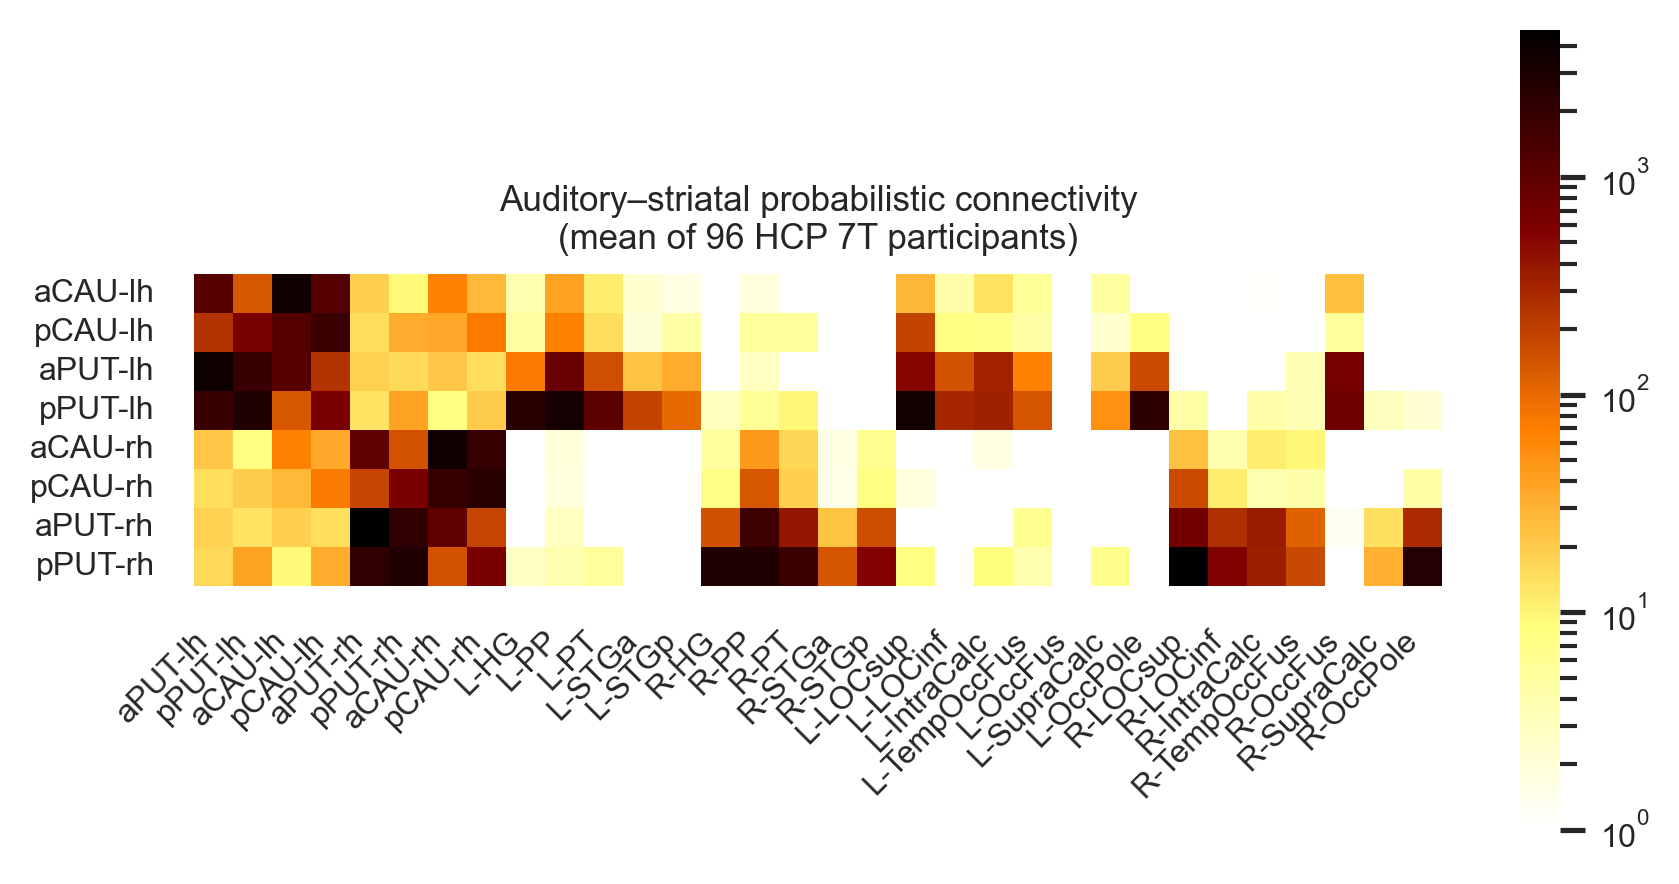

In [35]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df, ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

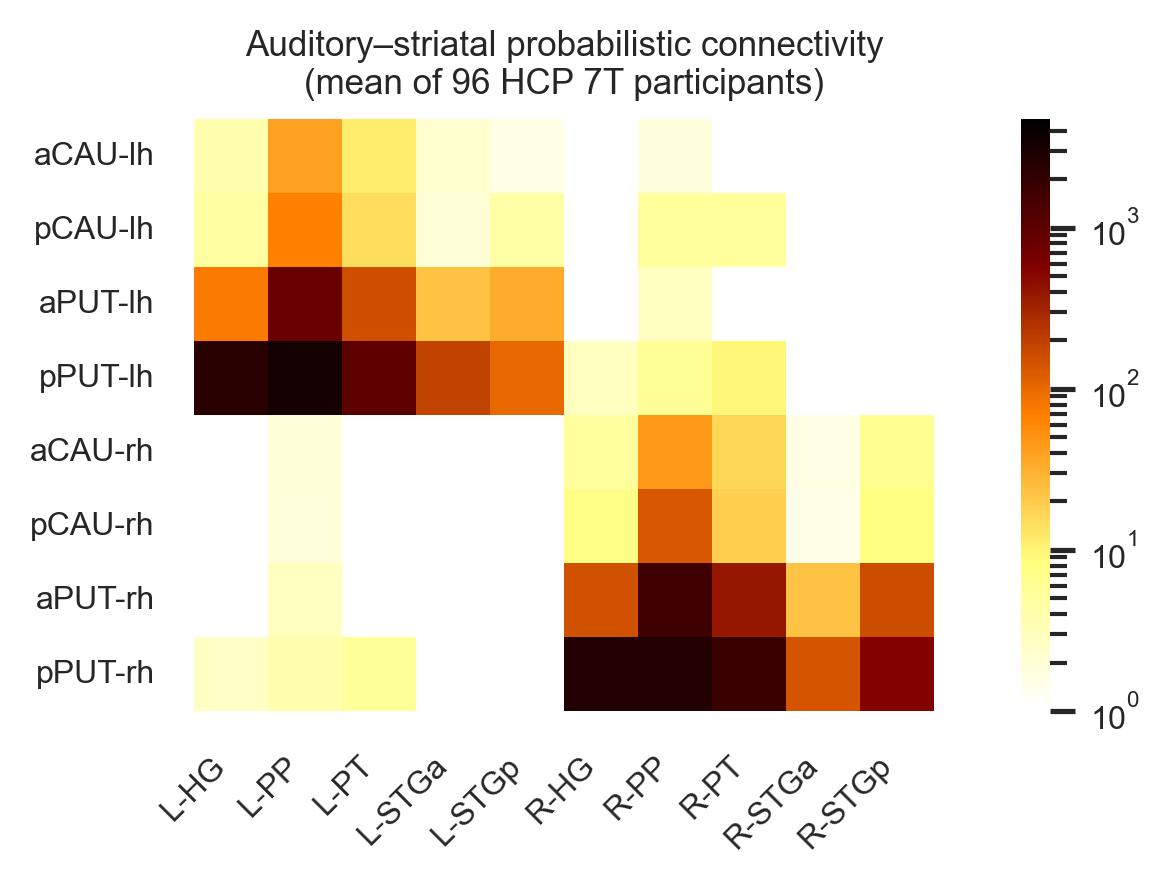

In [36]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df.iloc[:,8:18], ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

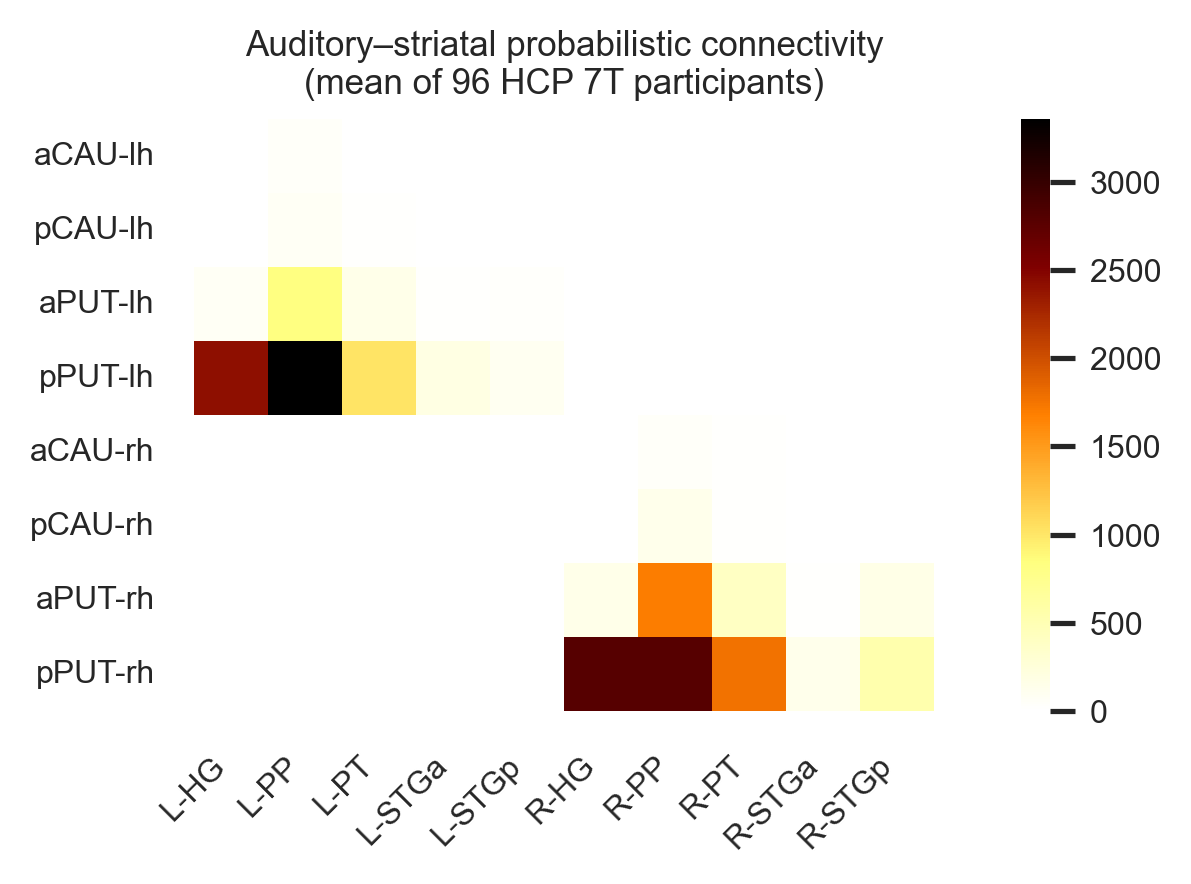

In [37]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df.iloc[:,8:18], ax=ax, cmap="afmhot_r",
            #norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

## Combine separate participants into single dataframe

In [38]:
participant_df_list = []
for i in range(connmats.shape[0]):
    df = pd.DataFrame(connmats[i], index=region_list, columns=region_list)
    df['participant_id'] = i
    participant_df_list.append(df)

In [39]:
striatum_rois = [r for r in region_list if r.startswith(('aPUT', 'pPUT', 'aCAU', 'pCAU'))]
cortex_rois = [r for r in region_list if r.startswith(('L-', 'R-'))]

filtered_df_list = []
for df in participant_df_list:
    sub_df = df.loc[striatum_rois, cortex_rois]
    sub_df['participant_id'] = df['participant_id'].iloc[0]
    filtered_df_list.append(sub_df)

In [40]:
rostral_caudal_map = {
    'aPUT-lh': 'Rostral', 'aCAU-lh': 'Rostral',
    'pPUT-lh': 'Caudal', 'pCAU-lh': 'Caudal',
    'aPUT-rh': 'Rostral', 'aCAU-rh': 'Rostral',
    'pPUT-rh': 'Caudal', 'pCAU-rh': 'Caudal'
}

for df in filtered_df_list:
    df['Rostral_Caudal'] = df.index.map(rostral_caudal_map)

In [41]:
caudate_putamen_map = {
    'aPUT-lh': 'Putamen', 'aCAU-lh': 'Caudate',
    'pPUT-lh': 'Putamen', 'pCAU-lh': 'Caudate',
    'aPUT-rh': 'Putamen', 'aCAU-rh': 'Caudate',
    'pPUT-rh': 'Putamen', 'pCAU-rh': 'Caudate'
}

for df in filtered_df_list:
    df['Caudate_Putamen'] = df.index.map(caudate_putamen_map)

In [42]:
all_df = pd.concat(filtered_df_list)
all_df = all_df.reset_index().rename(columns={'index': 'Striatum_ROI'})

In [43]:

# Melt to long format
all_long_df = all_df.melt(id_vars=['participant_id', 'Striatum_ROI', 'Rostral_Caudal', 'Caudate_Putamen'], 
                      value_vars=cortex_rois, 
                      var_name='Cortex_ROI', value_name='Connectivity')


In [44]:
all_long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity
0,0,aPUT-lh,Rostral,Putamen,L-HG,65.834432
1,0,pPUT-lh,Caudal,Putamen,L-HG,3104.246460
2,0,aCAU-lh,Rostral,Caudate,L-HG,4.357843
3,0,pCAU-lh,Caudal,Caudate,L-HG,19.704495
4,0,aPUT-rh,Rostral,Putamen,L-HG,0.000000


In [45]:
# Add hemisphere info before stripping labels
def get_striatum_hemisphere(roi):
    if roi.endswith('-lh'):
        return 'Left'
    elif roi.endswith('-rh'):
        return 'Right'
    else:
        return None

def get_cortex_hemisphere(roi):
    if roi.startswith('L-'):
        return 'Left'
    elif roi.startswith('R-'):
        return 'Right'
    else:
        return None

all_long_df['striatum_hemisphere'] = all_long_df['Striatum_ROI'].apply(get_striatum_hemisphere)
all_long_df['cortex_hemisphere'] = all_long_df['Cortex_ROI'].apply(get_cortex_hemisphere)

# Keep only rows where hemispheres match
all_long_df = all_long_df[all_long_df['striatum_hemisphere'] == all_long_df['cortex_hemisphere']]

# Optionally, create a single 'hemisphere' column and strip hemisphere labels
all_long_df['hemisphere'] = all_long_df['striatum_hemisphere']
all_long_df['Striatum_ROI'] = all_long_df['Striatum_ROI'].apply(lambda x: x[:-3] if x.endswith(('-lh', '-rh')) else x)
all_long_df['Cortex_ROI'] = all_long_df['Cortex_ROI'].apply(lambda x: x[2:] if x.startswith(('L-', 'R-')) else x)

In [46]:
all_long_df.shape

(9216, 9)

In [47]:
all_long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity,striatum_hemisphere,cortex_hemisphere,hemisphere
0,0,aPUT,Rostral,Putamen,HG,65.834432,Left,Left,Left
1,0,pPUT,Caudal,Putamen,HG,3104.246460,Left,Left,Left
2,0,aCAU,Rostral,Caudate,HG,4.357843,Left,Left,Left
3,0,pCAU,Caudal,Caudate,HG,19.704495,Left,Left,Left
8,1,aPUT,Rostral,Putamen,HG,71.307784,Left,Left,Left


In [48]:
all_long_df.Cortex_ROI.unique()

array(['HG', 'PP', 'PT', 'STGa', 'STGp', 'LOCsup', 'LOCinf', 'IntraCalc',
       'TempOccFus', 'OccFus', 'SupraCalc', 'OccPole'], dtype=object)

In [49]:
auditory_rois = ['HG', 'PP', 'PT', 'STGp', 'STGa']
long_df = all_long_df[all_long_df['Cortex_ROI'].isin(auditory_rois)]


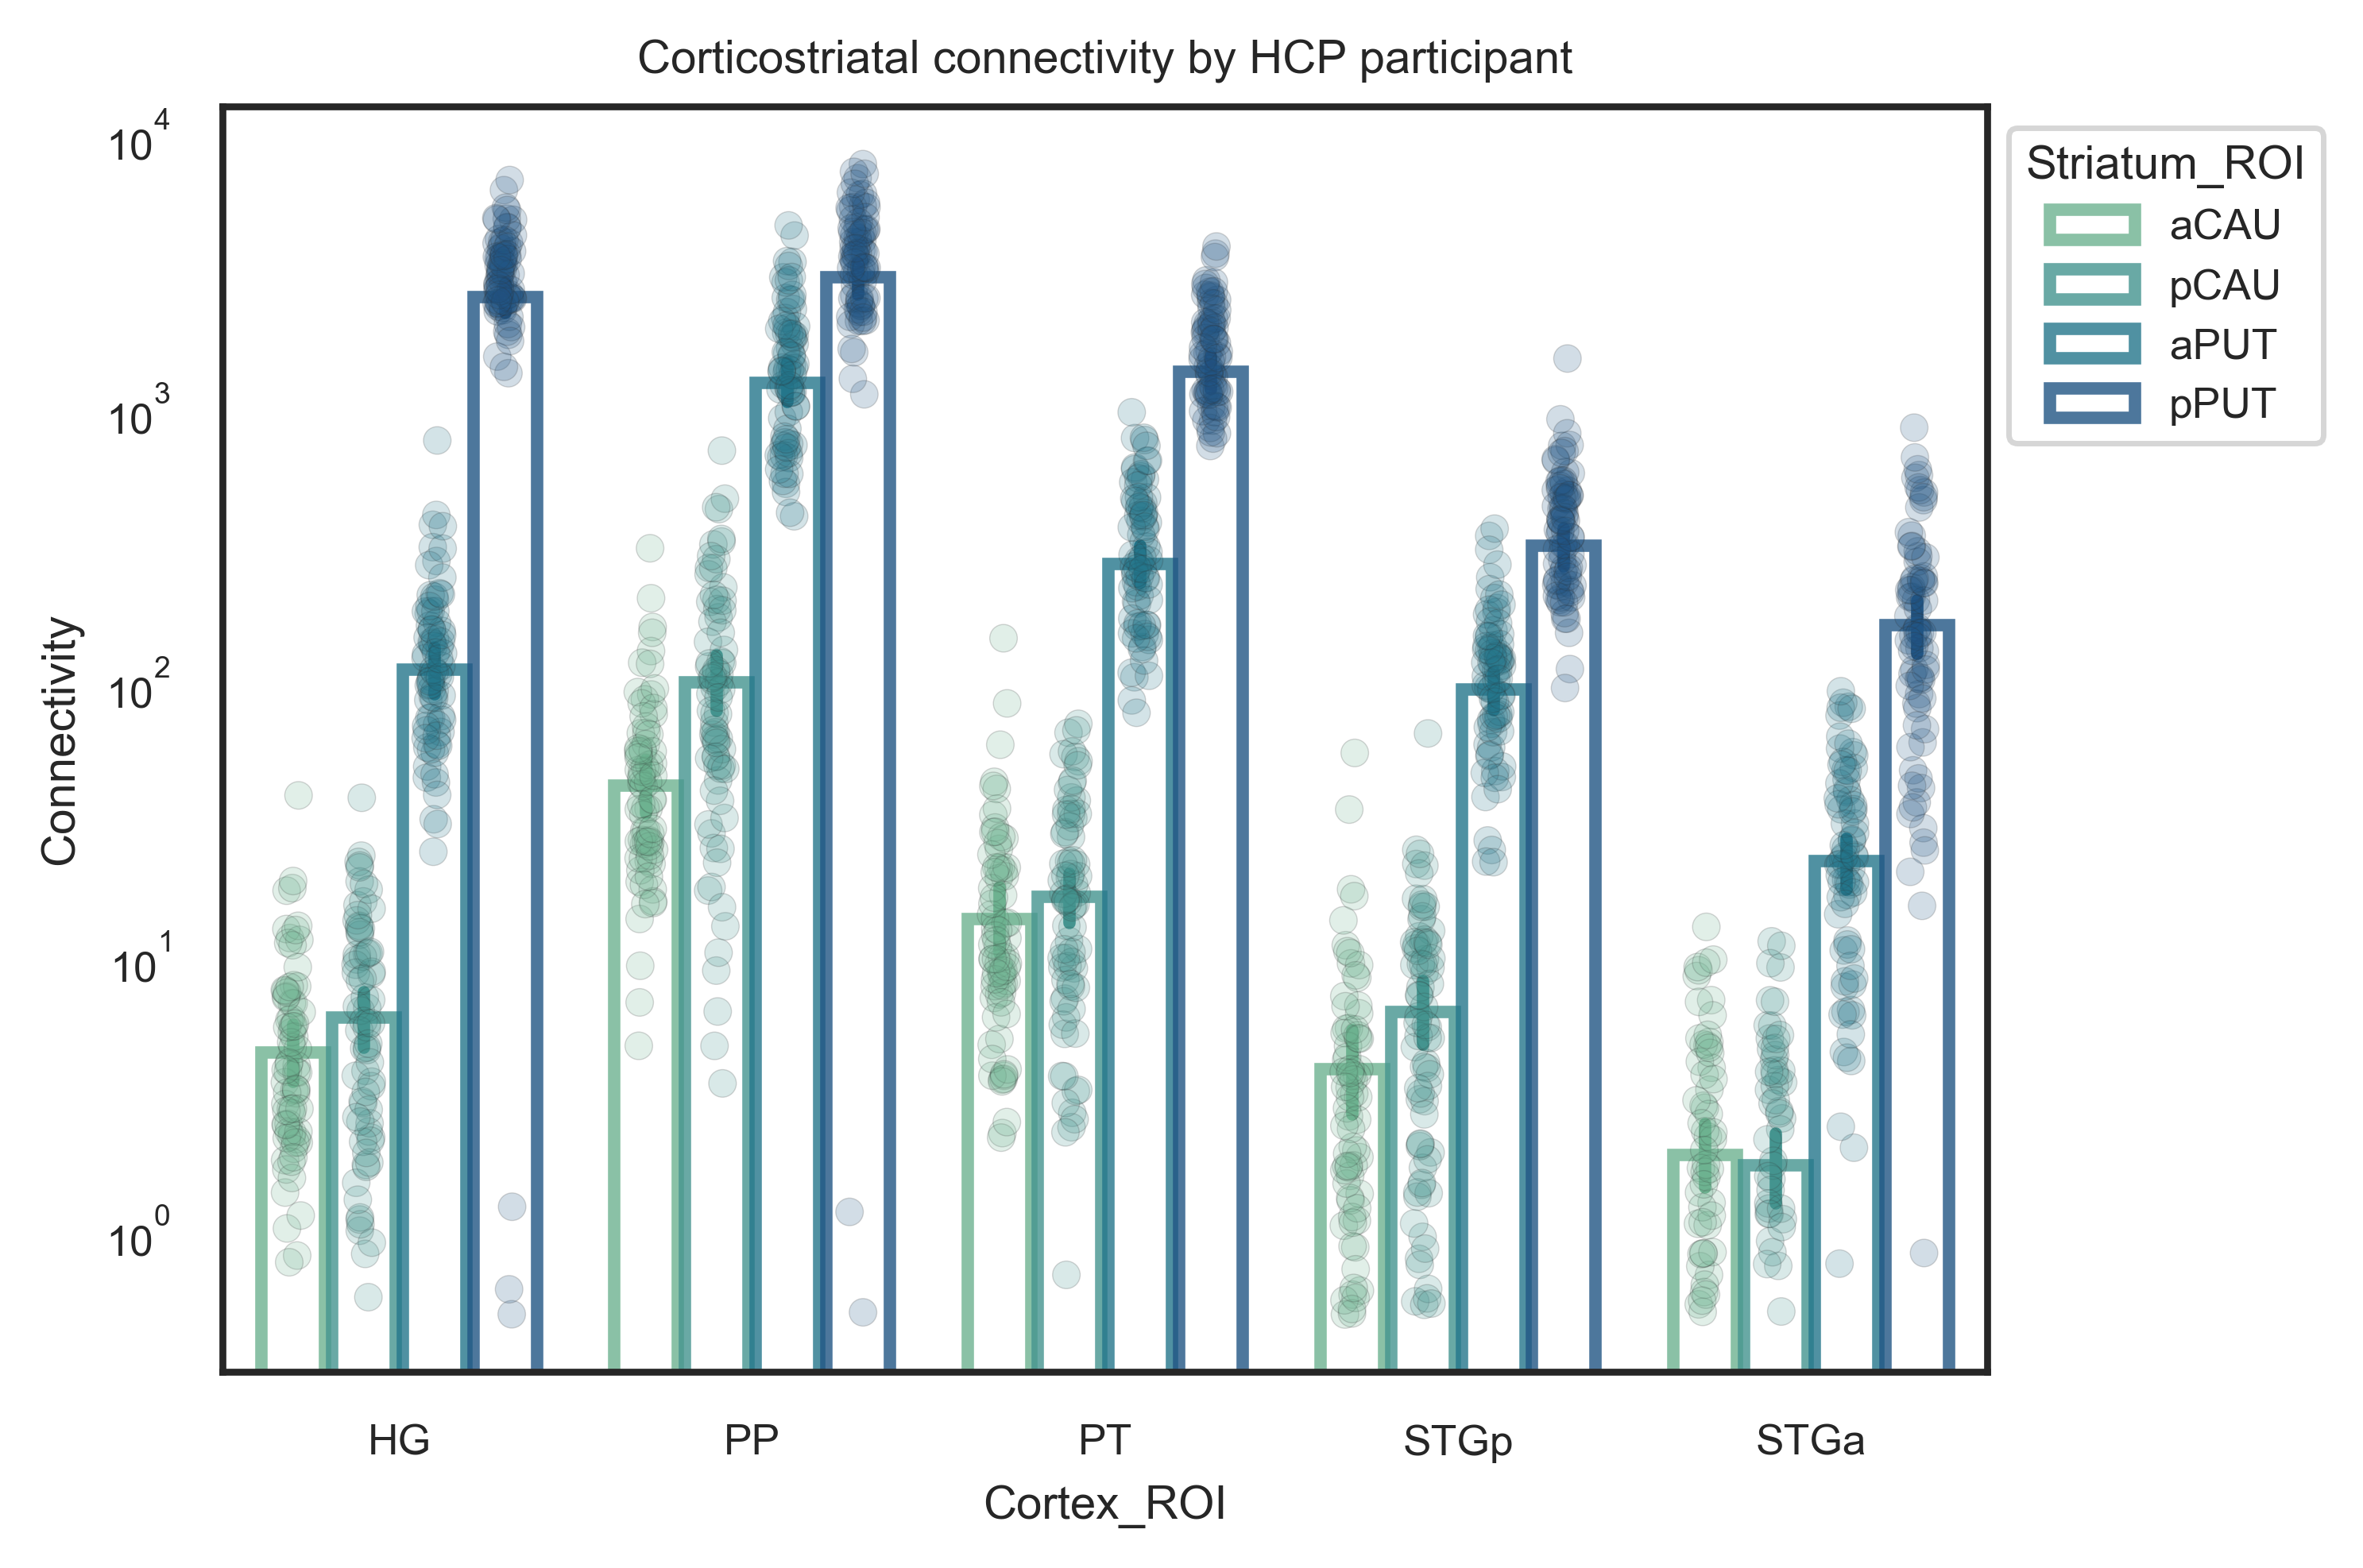

In [71]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'Striatum_ROI',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=500)

sns.barplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              order=auditory_rois,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.8, gap=0.1, fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              order=auditory_rois,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.2,
              alpha=0.2,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
#ax.set_ylim([-5, 5])

fig.tight_layout()


## Across-participant statistics

In [150]:
from statsmodels.stats.anova import AnovaRM
import pingouin as pg

### All factors

In [151]:
# Mixed-Effects ANOVA with all factors and interactions
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere',]).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Caudate_Putamen,253.5474,1.0000,95.0000,0.0000
Rostral_Caudal,217.9354,1.0000,95.0000,0.0000
Cortex_ROI,200.9688,4.0000,380.0000,0.0000
hemisphere,32.7078,1.0000,95.0000,0.0000
Caudate_Putamen:Rostral_Caudal,217.8958,1.0000,95.0000,0.0000
Caudate_Putamen:Cortex_ROI,195.8213,4.0000,380.0000,0.0000
Rostral_Caudal:Cortex_ROI,113.5877,4.0000,380.0000,0.0000
Caudate_Putamen:hemisphere,29.7578,1.0000,95.0000,0.0000
Rostral_Caudal:hemisphere,1.0827,1.0000,95.0000,0.3007
Cortex_ROI:hemisphere,11.8480,4.0000,380.0000,0.0000


### No hemisphere

In [152]:
# Mixed-Effects ANOVA with all factors and interactions
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI']).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Caudate_Putamen,253.5474,1.0000,95.0000,0.0000
Rostral_Caudal,217.9354,1.0000,95.0000,0.0000
Cortex_ROI,200.9688,4.0000,380.0000,0.0000
Caudate_Putamen:Rostral_Caudal,217.8958,1.0000,95.0000,0.0000
Caudate_Putamen:Cortex_ROI,195.8213,4.0000,380.0000,0.0000
Rostral_Caudal:Cortex_ROI,113.5877,4.0000,380.0000,0.0000
Caudate_Putamen:Rostral_Caudal:Cortex_ROI,113.1496,4.0000,380.0000,0.0000


### Caudate–Putamen

In [153]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Cortex_ROI', 'hemisphere',]).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Caudate_Putamen,253.5474,1.0000,95.0000,0.0000
Cortex_ROI,200.9688,4.0000,380.0000,0.0000
hemisphere,32.7078,1.0000,95.0000,0.0000
Caudate_Putamen:Cortex_ROI,195.8213,4.0000,380.0000,0.0000
Caudate_Putamen:hemisphere,29.7578,1.0000,95.0000,0.0000
Cortex_ROI:hemisphere,11.8480,4.0000,380.0000,0.0000
Caudate_Putamen:Cortex_ROI:hemisphere,12.9930,4.0000,380.0000,0.0000


In [154]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Caudate_Putamen', 'Cortex_ROI'],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Caudate_Putamen', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Caudate_Putamen', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Caudate_Putamen,A,B,T,dof,p_unc,p_corr,BF10
0,Caudate_Putamen,-,Caudate,Putamen,-15.923171,95.0,1.458177e-28,NaN,2.328e+25
1,Cortex_ROI,-,HG,PP,-10.464001,95.0,1.691168e-17,2.113960e-17,3.415e+14
2,Cortex_ROI,-,HG,PT,10.423028,95.0,2.067593e-17,2.297325e-17,2.808e+14
3,Cortex_ROI,-,HG,STGa,15.094147,95.0,5.638589e-27,2.819294e-26,6.43e+23
4,Cortex_ROI,-,HG,STGp,14.402568,95.0,1.269706e-25,3.174265e-25,3.027e+22
5,Cortex_ROI,-,PP,PT,13.106870,95.0,5.056999e-23,8.428332e-23,8.554e+19
6,Cortex_ROI,-,PP,STGa,15.377079,95.0,1.604069e-27,1.604069e-26,2.209e+24
7,Cortex_ROI,-,PP,STGp,14.994341,95.0,8.806210e-27,2.935403e-26,4.151e+23
8,Cortex_ROI,-,PT,STGa,13.630701,95.0,4.391922e-24,8.783845e-24,9.374e+20
9,Cortex_ROI,-,PT,STGp,12.777748,95.0,2.383639e-22,3.405199e-22,1.874e+19


In [155]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Cortex_ROI', 'Caudate_Putamen', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Cortex_ROI,-,HG,PP,-10.464001,95.0,1.691168e-17,2.113960e-17,3.415e+14
1,Cortex_ROI,-,HG,PT,10.423028,95.0,2.067593e-17,2.297325e-17,2.808e+14
2,Cortex_ROI,-,HG,STGa,15.094147,95.0,5.638589e-27,2.819294e-26,6.43e+23
3,Cortex_ROI,-,HG,STGp,14.402568,95.0,1.269706e-25,3.174265e-25,3.027e+22
4,Cortex_ROI,-,PP,PT,13.106870,95.0,5.056999e-23,8.428332e-23,8.554e+19
5,Cortex_ROI,-,PP,STGa,15.377079,95.0,1.604069e-27,1.604069e-26,2.209e+24
6,Cortex_ROI,-,PP,STGp,14.994341,95.0,8.806210e-27,2.935403e-26,4.151e+23
7,Cortex_ROI,-,PT,STGa,13.630701,95.0,4.391922e-24,8.783845e-24,9.374e+20
8,Cortex_ROI,-,PT,STGp,12.777748,95.0,2.383639e-22,3.405199e-22,1.874e+19
9,Cortex_ROI,-,STGa,STGp,-9.039080,95.0,1.870377e-14,1.870377e-14,3.737e+11


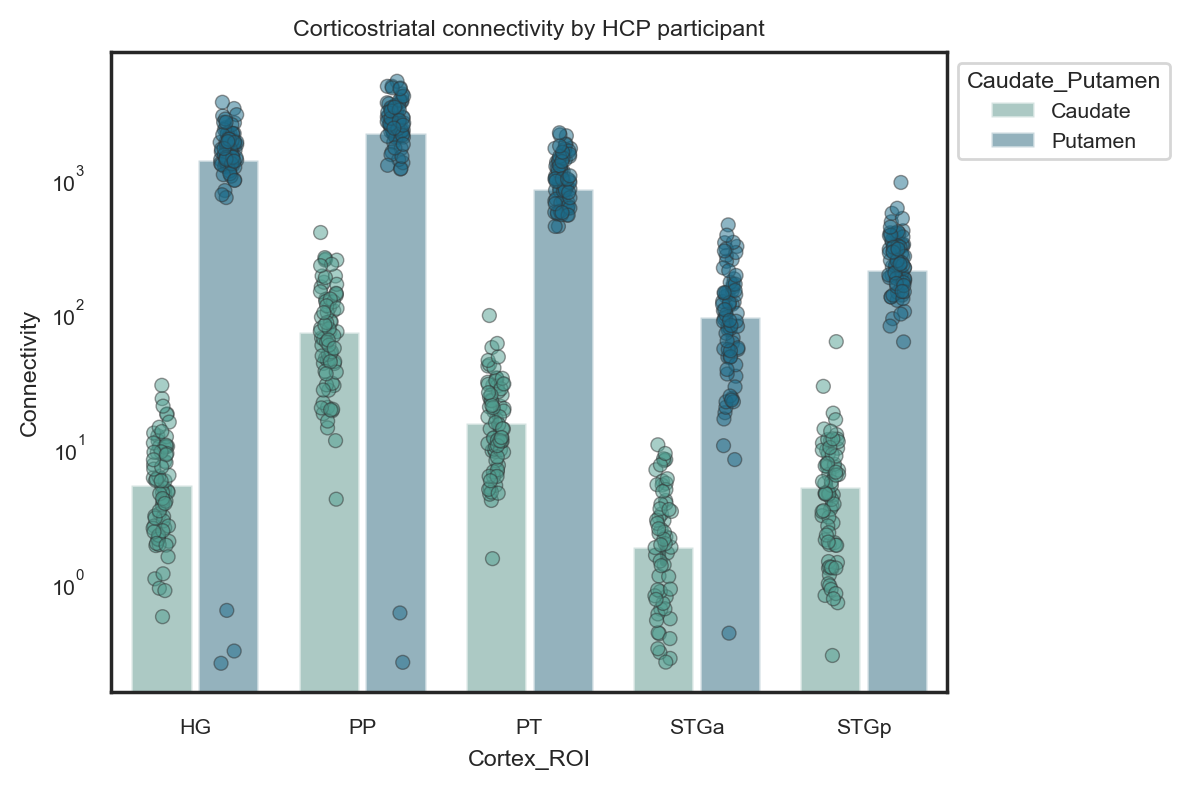

In [ ]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'Caudate_Putamen',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=200)

sns.barplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              hue='Caudate_Putamen', #hue_order=['early', 'middle', 'final'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.5, gap=0.1, #fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              hue='Caudate_Putamen', #hue_order=['early', 'middle', 'final'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.5,
              alpha=0.5,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
#ax.set_ylim([-5, 5])

fig.tight_layout()


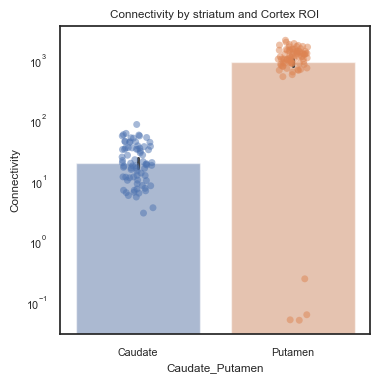

In [157]:
df_collapsed = long_df.groupby(["participant_id", 'Caudate_Putamen',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(4, 4))
sns.barplot(x='Caudate_Putamen', y='Connectivity', hue='Caudate_Putamen', data=df_collapsed, alpha=0.5)
sns.stripplot(x='Caudate_Putamen', y='Connectivity', hue='Caudate_Putamen', data=df_collapsed, alpha=0.5)

plt.title('Connectivity by striatum and Cortex ROI')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.yscale('log')
plt.show()

In [158]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Cortex_ROI',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p_unc,p_corr,BF10
0,hemisphere,-,Left,Right,-5.719075,95.0,1.236208e-07,NaN,1.014e+05
1,Cortex_ROI,-,HG,PP,-10.464001,95.0,1.691168e-17,2.113960e-17,3.415e+14
2,Cortex_ROI,-,HG,PT,10.423028,95.0,2.067593e-17,2.297325e-17,2.808e+14
3,Cortex_ROI,-,HG,STGa,15.094147,95.0,5.638589e-27,2.819294e-26,6.43e+23
4,Cortex_ROI,-,HG,STGp,14.402568,95.0,1.269706e-25,3.174265e-25,3.027e+22
5,Cortex_ROI,-,PP,PT,13.106870,95.0,5.056999e-23,8.428332e-23,8.554e+19
6,Cortex_ROI,-,PP,STGa,15.377079,95.0,1.604069e-27,1.604069e-26,2.209e+24
7,Cortex_ROI,-,PP,STGp,14.994341,95.0,8.806210e-27,2.935403e-26,4.151e+23
8,Cortex_ROI,-,PT,STGa,13.630701,95.0,4.391922e-24,8.783845e-24,9.374e+20
9,Cortex_ROI,-,PT,STGp,12.777748,95.0,2.383639e-22,3.405199e-22,1.874e+19


In [159]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Cortex_ROI,-,HG,PP,-10.464001,95.0,1.691168e-17,2.113960e-17,3.415e+14
1,Cortex_ROI,-,HG,PT,10.423028,95.0,2.067593e-17,2.297325e-17,2.808e+14
2,Cortex_ROI,-,HG,STGa,15.094147,95.0,5.638589e-27,2.819294e-26,6.43e+23
3,Cortex_ROI,-,HG,STGp,14.402568,95.0,1.269706e-25,3.174265e-25,3.027e+22
4,Cortex_ROI,-,PP,PT,13.106870,95.0,5.056999e-23,8.428332e-23,8.554e+19
5,Cortex_ROI,-,PP,STGa,15.377079,95.0,1.604069e-27,1.604069e-26,2.209e+24
6,Cortex_ROI,-,PP,STGp,14.994341,95.0,8.806210e-27,2.935403e-26,4.151e+23
7,Cortex_ROI,-,PT,STGa,13.630701,95.0,4.391922e-24,8.783845e-24,9.374e+20
8,Cortex_ROI,-,PT,STGp,12.777748,95.0,2.383639e-22,3.405199e-22,1.874e+19
9,Cortex_ROI,-,STGa,STGp,-9.039080,95.0,1.870377e-14,1.870377e-14,3.737e+11


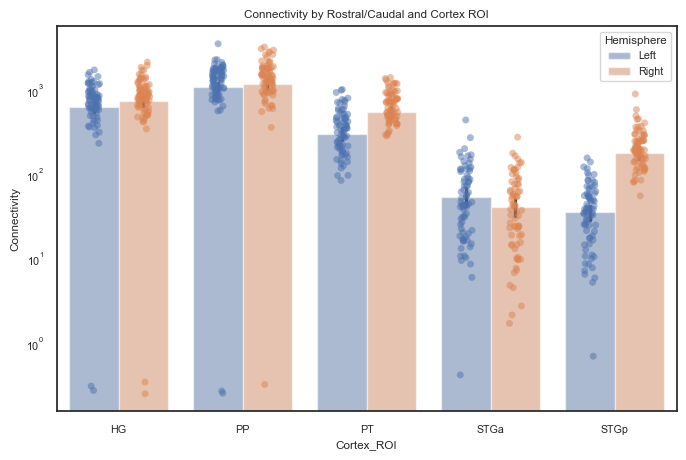

In [160]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

In [161]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Striatum_ROI', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise)

Available columns: Index(['Contrast', 'Striatum_ROI', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Striatum_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Striatum_ROI,-,aCAU,aPUT,-12.826335,95.0,1.894655e-22,2.841982e-22,2.347e+19
1,Striatum_ROI,-,aCAU,pCAU,-5.365075,95.0,5.692212e-07,5.692212e-07,2.38e+04
2,Striatum_ROI,-,aCAU,pPUT,-15.768672,95.0,2.862783e-28,8.605865e-28,1.2e+25
3,Striatum_ROI,-,aPUT,pCAU,12.492087,95.0,9.237926e-22,1.108551e-21,4.977e+18
4,Striatum_ROI,-,aPUT,pPUT,-14.768355,95.0,2.427504e-26,4.855008e-26,1.534e+23
5,Striatum_ROI,-,pCAU,pPUT,-15.768206,95.0,2.868622e-28,8.605865e-28,1.198e+25
6,hemisphere,-,Left,Right,-5.719075,95.0,1.236208e-07,NaN,1.014e+05
7,Striatum_ROI * hemisphere,aCAU,Left,Right,-1.511624,95.0,1.339489e-01,1.339489e-01,0.339
8,Striatum_ROI * hemisphere,aPUT,Left,Right,-8.391311,95.0,4.479412e-13,1.791765e-12,1.719e+10
9,Striatum_ROI * hemisphere,pCAU,Left,Right,-4.380834,95.0,3.044523e-05,6.089046e-05,563.666


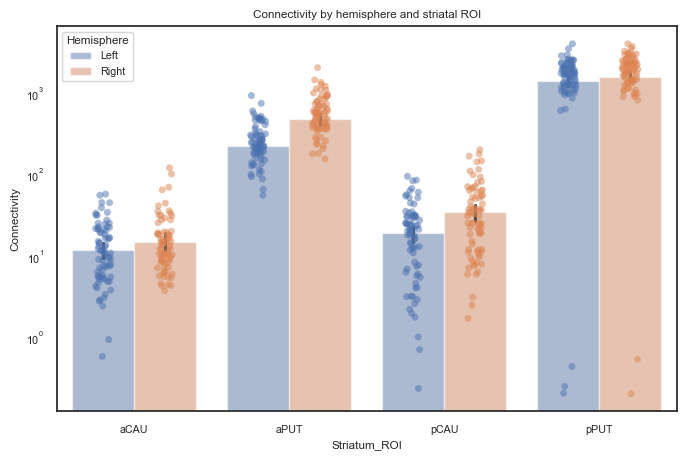

In [162]:
df_collapsed = long_df.groupby(["participant_id", 'Striatum_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by hemisphere and striatal ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

### Rostral–caudal

In [163]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Rostral_Caudal', 'hemisphere', 'Cortex_ROI']).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Rostral_Caudal,217.9354,1.0000,95.0000,0.0000
hemisphere,32.7078,1.0000,95.0000,0.0000
Cortex_ROI,200.9688,4.0000,380.0000,0.0000
Rostral_Caudal:hemisphere,1.0827,1.0000,95.0000,0.3007
Rostral_Caudal:Cortex_ROI,113.5877,4.0000,380.0000,0.0000
hemisphere:Cortex_ROI,11.8480,4.0000,380.0000,0.0000
Rostral_Caudal:hemisphere:Cortex_ROI,43.7575,4.0000,380.0000,0.0000


In [164]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p_unc,p_corr,BF10
0,hemisphere,-,Left,Right,-5.719075,95.0,1.236208e-07,NaN,1.014e+05
1,Rostral_Caudal,-,Caudal,Rostral,14.762634,95.0,2.490828e-26,NaN,1.496e+23
2,hemisphere * Rostral_Caudal,Left,Caudal,Rostral,14.226456,95.0,2.832388e-25,5.664776e-25,1.378e+22
3,hemisphere * Rostral_Caudal,Right,Caudal,Rostral,13.099414,95.0,5.237119e-23,5.237119e-23,8.265e+19


In [165]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Rostral_Caudal', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Rostral_Caudal', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Rostral_Caudal', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Rostral_Caudal,A,B,T,dof,p_unc,p_corr,BF10
0,Rostral_Caudal,-,Caudal,Rostral,14.762634,95.0,2.490828e-26,NaN,1.496e+23
1,hemisphere,-,Left,Right,-5.719075,95.0,1.236208e-07,NaN,1.014e+05
2,Rostral_Caudal * hemisphere,Caudal,Left,Right,-2.993717,95.0,3.513019e-03,3.513019e-03,7.292
3,Rostral_Caudal * hemisphere,Rostral,Left,Right,-8.401725,95.0,4.257227e-13,8.514454e-13,1.806e+10


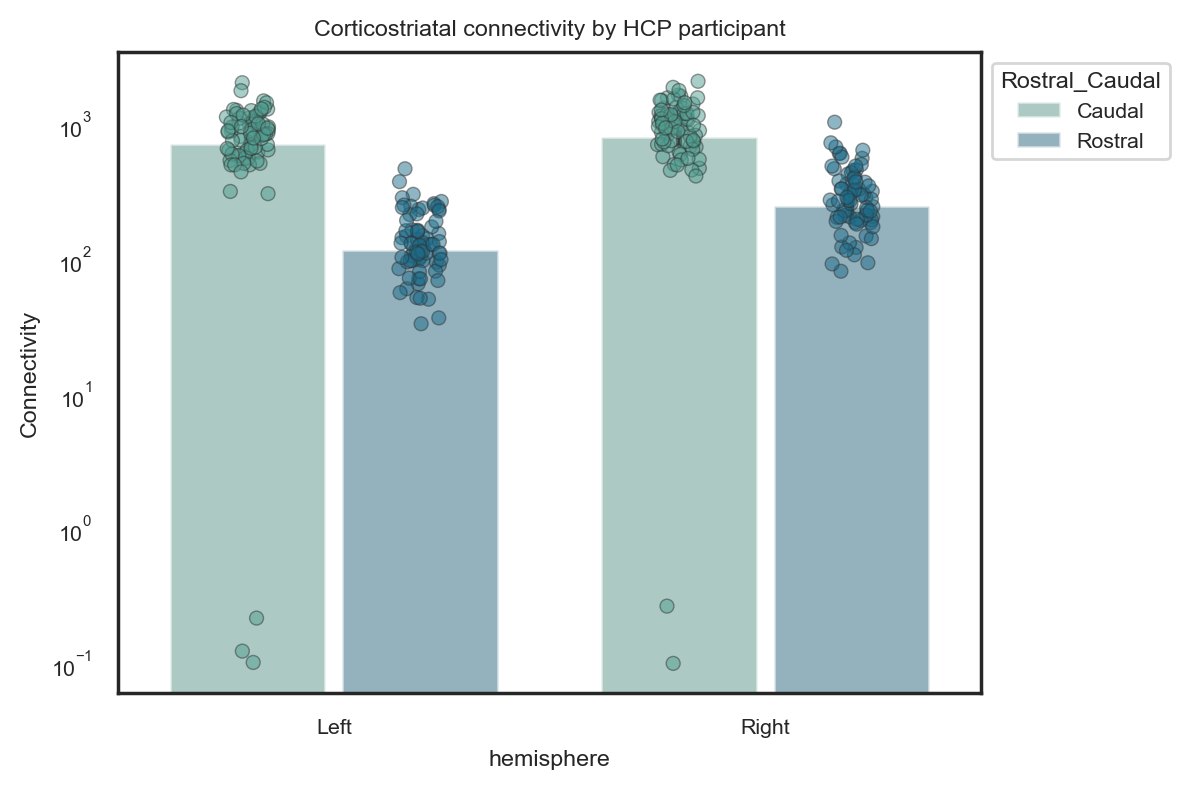

In [166]:
df_collapsed = long_df.groupby(["participant_id", 'hemisphere', 'Rostral_Caudal',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=200)

sns.barplot(data=df_collapsed, 
              x='hemisphere', y='Connectivity', 
              hue='Rostral_Caudal', #hue_order=['early', 'middle', 'final'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.5, gap=0.1, #fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='hemisphere', y='Connectivity', 
              hue='Rostral_Caudal', #hue_order=['early', 'middle', 'final'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.5,
              alpha=0.5,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
#ax.set_ylim([-5, 5])

fig.tight_layout()


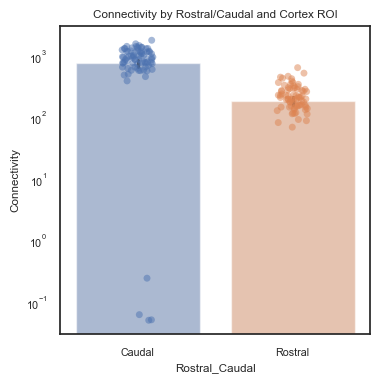

In [167]:
df_collapsed = long_df.groupby(["participant_id", 'Rostral_Caudal',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(4, 4))
sns.barplot(x='Rostral_Caudal', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, alpha=0.5)
sns.stripplot(x='Rostral_Caudal', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, alpha=0.5)

plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.yscale('log')
plt.show()

In [168]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Cortex_ROI,-,HG,PP,-10.464001,95.0,1.691168e-17,2.113960e-17,3.415e+14
1,Cortex_ROI,-,HG,PT,10.423028,95.0,2.067593e-17,2.297325e-17,2.808e+14
2,Cortex_ROI,-,HG,STGa,15.094147,95.0,5.638589e-27,2.819294e-26,6.43e+23
3,Cortex_ROI,-,HG,STGp,14.402568,95.0,1.269706e-25,3.174265e-25,3.027e+22
4,Cortex_ROI,-,PP,PT,13.106870,95.0,5.056999e-23,8.428332e-23,8.554e+19
5,Cortex_ROI,-,PP,STGa,15.377079,95.0,1.604069e-27,1.604069e-26,2.209e+24
6,Cortex_ROI,-,PP,STGp,14.994341,95.0,8.806210e-27,2.935403e-26,4.151e+23
7,Cortex_ROI,-,PT,STGa,13.630701,95.0,4.391922e-24,8.783845e-24,9.374e+20
8,Cortex_ROI,-,PT,STGp,12.777748,95.0,2.383639e-22,3.405199e-22,1.874e+19
9,Cortex_ROI,-,STGa,STGp,-9.039080,95.0,1.870377e-14,1.870377e-14,3.737e+11


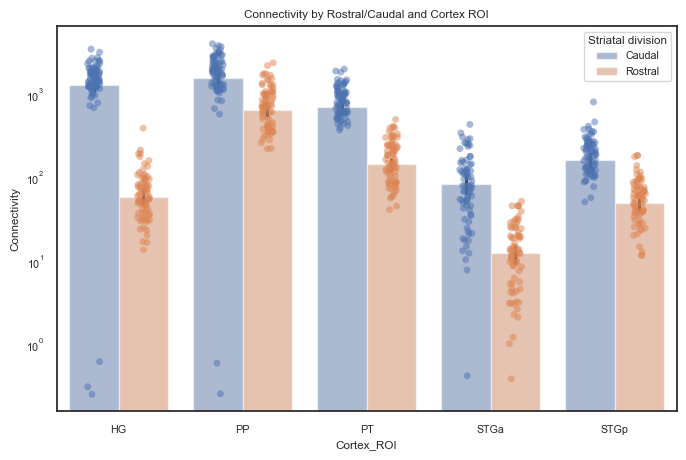

In [169]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'Rostral_Caudal',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
plt.legend(title='Striatal division') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

In [175]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Cortex_ROI,-,HG,PP,-10.464001,95.0,1.691168e-17,2.113960e-17,3.415e+14
1,Cortex_ROI,-,HG,PT,10.423028,95.0,2.067593e-17,2.297325e-17,2.808e+14
2,Cortex_ROI,-,HG,STGa,15.094147,95.0,5.638589e-27,2.819294e-26,6.43e+23
3,Cortex_ROI,-,HG,STGp,14.402568,95.0,1.269706e-25,3.174265e-25,3.027e+22
4,Cortex_ROI,-,PP,PT,13.106870,95.0,5.056999e-23,8.428332e-23,8.554e+19
5,Cortex_ROI,-,PP,STGa,15.377079,95.0,1.604069e-27,1.604069e-26,2.209e+24
6,Cortex_ROI,-,PP,STGp,14.994341,95.0,8.806210e-27,2.935403e-26,4.151e+23
7,Cortex_ROI,-,PT,STGa,13.630701,95.0,4.391922e-24,8.783845e-24,9.374e+20
8,Cortex_ROI,-,PT,STGp,12.777748,95.0,2.383639e-22,3.405199e-22,1.874e+19
9,Cortex_ROI,-,STGa,STGp,-9.039080,95.0,1.870377e-14,1.870377e-14,3.737e+11


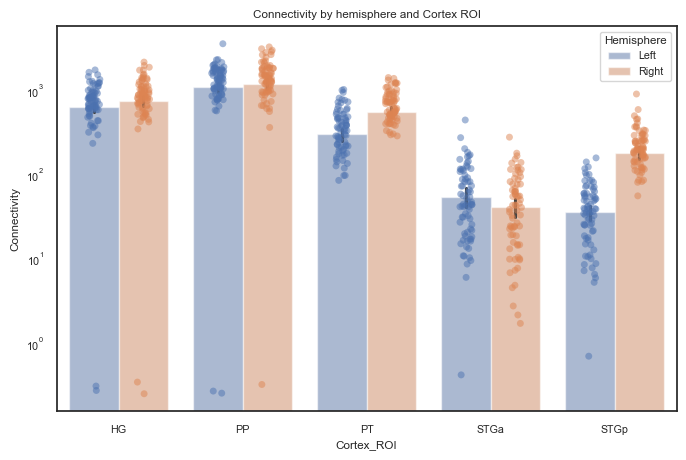

In [176]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by hemisphere and Cortex ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

In [177]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Striatum_ROI', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise)

Available columns: Index(['Contrast', 'Striatum_ROI', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Striatum_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Striatum_ROI,-,aCAU,aPUT,-12.826335,95.0,1.894655e-22,2.841982e-22,2.347e+19
1,Striatum_ROI,-,aCAU,pCAU,-5.365075,95.0,5.692212e-07,5.692212e-07,2.38e+04
2,Striatum_ROI,-,aCAU,pPUT,-15.768672,95.0,2.862783e-28,8.605865e-28,1.2e+25
3,Striatum_ROI,-,aPUT,pCAU,12.492087,95.0,9.237926e-22,1.108551e-21,4.977e+18
4,Striatum_ROI,-,aPUT,pPUT,-14.768355,95.0,2.427504e-26,4.855008e-26,1.534e+23
5,Striatum_ROI,-,pCAU,pPUT,-15.768206,95.0,2.868622e-28,8.605865e-28,1.198e+25
6,hemisphere,-,Left,Right,-5.719075,95.0,1.236208e-07,NaN,1.014e+05
7,Striatum_ROI * hemisphere,aCAU,Left,Right,-1.511624,95.0,1.339489e-01,1.339489e-01,0.339
8,Striatum_ROI * hemisphere,aPUT,Left,Right,-8.391311,95.0,4.479412e-13,1.791765e-12,1.719e+10
9,Striatum_ROI * hemisphere,pCAU,Left,Right,-4.380834,95.0,3.044523e-05,6.089046e-05,563.666


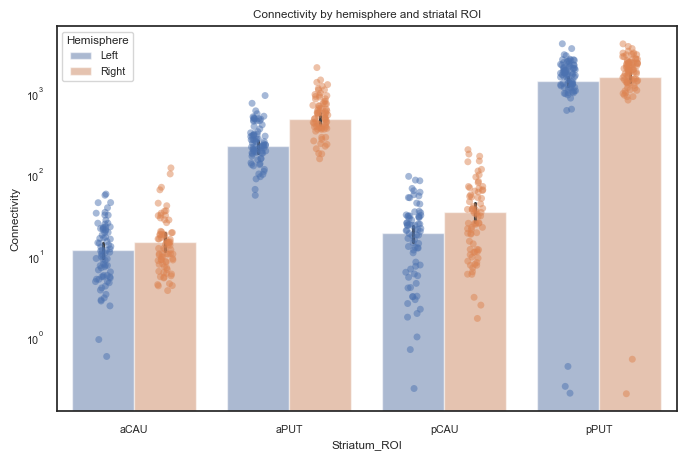

In [178]:
df_collapsed = long_df.groupby(["participant_id", 'Striatum_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by hemisphere and striatal ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()